# Proyecto de Inteligencia Artificial  
## Clasificación de riesgo crediticio (`Credit Score`)

En este proyecto se analiza un conjunto de datos de clientes con información demográfica y financiera, con el objetivo de **predecir el nivel de riesgo crediticio** de cada persona.

El flujo general será:

1. Exploración y descripción del dataset.
2. Preprocesamiento de datos (limpieza, tratamiento de nulos, codificación, escalado).
3. Entrenamiento y evaluación de modelos de clasificación.
4. Reducción de dimensionalidad con PCA.
5. Clustering (aprendizaje no supervisado).
6. Análisis y conclusiones finales.

# Descripción Detallada del Dataset

In [349]:
import pandas as pd
pd.set_option("display.max_columns", 50)

df = pd.read_csv("credit_score.csv")

# limpiar posibles espacios en nombres de columnas (por si acaso)
df.columns = df.columns.str.strip()

df.head()

C:\Users\COMPU\AppData\Local\Temp\ipykernel_13180\502030997.py:4: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("credit_score.csv")


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [350]:
# Tamaño del dataset (filas, columnas)
df.shape

(100000, 28)

In [351]:
# Lista de columnas
df.columns.tolist()

['ID',
 'Customer_ID',
 'Month',
 'Name',
 'Age',
 'SSN',
 'Occupation',
 'Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Type_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Credit_Mix',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Credit_History_Age',
 'Payment_of_Min_Amount',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Payment_Behaviour',
 'Monthly_Balance',
 'Credit_Score']

In [352]:
df.isnull().sum().sort_values(ascending=False).head(15)

Monthly_Inhand_Salary       15002
Type_of_Loan                11408
Name                         9985
Credit_History_Age           9030
Num_of_Delayed_Payment       7002
Amount_invested_monthly      4479
Num_Credit_Inquiries         1965
Monthly_Balance              1200
ID                              0
Changed_Credit_Limit            0
Payment_Behaviour               0
Total_EMI_per_month             0
Payment_of_Min_Amount           0
Credit_Utilization_Ratio        0
Outstanding_Debt                0
dtype: int64

In [353]:
# Información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [354]:
#resumen estadístico:
df.describe(include="all")

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,100000,100000,100000,84998.000000,100000.000000,100000.00000,100000.000000,100000,88592,100000.000000,92998,100000,98035.000000,100000,100000,100000.000000,90970,100000,100000.000000,95521,100000,98800,100000
unique,100000,12500,8,10139,1788,12501,16,18940,NaN,NaN,NaN,NaN,434,6260,NaN,749,4384,NaN,4,13178,NaN,404,3,NaN,91049,7,98792,3
top,0x1602,CUS_0xd40,January,Langep,38,#F%$D@*&8,_______,36585.12,NaN,NaN,NaN,NaN,3,Not Specified,NaN,19,_,NaN,Standard,1360.45,NaN,15 Years and 11 Months,Yes,NaN,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,12500,44,2833,5572,7062,16,NaN,NaN,NaN,NaN,14386,1408,NaN,5327,2091,NaN,36479,24,NaN,446,52326,NaN,4305,25513,9,53174
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4194.170850,17.091280,22.47443,72.466040,NaN,NaN,21.068780,NaN,NaN,27.754251,NaN,NaN,32.285173,NaN,NaN,1403.118217,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3183.686167,117.404834,129.05741,466.422621,NaN,NaN,14.860104,NaN,NaN,193.177339,NaN,NaN,5.116875,NaN,NaN,8306.041270,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303.645417,-1.000000,0.00000,1.000000,NaN,NaN,-5.000000,NaN,NaN,0.000000,NaN,NaN,20.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1625.568229,3.000000,4.00000,8.000000,NaN,NaN,10.000000,NaN,NaN,3.000000,NaN,NaN,28.052567,NaN,NaN,30.306660,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3093.745000,6.000000,5.00000,13.000000,NaN,NaN,18.000000,NaN,NaN,6.000000,NaN,NaN,32.305784,NaN,NaN,69.249473,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5957.448333,7.000000,7.00000,20.000000,NaN,NaN,28.000000,NaN,NaN,9.000000,NaN,NaN,36.496663,NaN,NaN,161.224249,NaN,NaN,NaN,NaN


In [355]:
#distribución de la variable objetivo
df["Credit_Score"].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

In [356]:
#porcentajes
df["Credit_Score"].value_counts(normalize=True)

Credit_Score
Standard    0.53174
Poor        0.28998
Good        0.17828
Name: proportion, dtype: float64

# PREPROCESAMIENTO

In [357]:
#Revisar valores nulos por columna
df.isnull().sum().sort_values(ascending=False)

Monthly_Inhand_Salary       15002
Type_of_Loan                11408
Name                         9985
Credit_History_Age           9030
Num_of_Delayed_Payment       7002
Amount_invested_monthly      4479
Num_Credit_Inquiries         1965
Monthly_Balance              1200
ID                              0
Changed_Credit_Limit            0
Payment_Behaviour               0
Total_EMI_per_month             0
Payment_of_Min_Amount           0
Credit_Utilization_Ratio        0
Outstanding_Debt                0
Credit_Mix                      0
Delay_from_due_date             0
Customer_ID                     0
Num_of_Loan                     0
Interest_Rate                   0
Num_Credit_Card                 0
Num_Bank_Accounts               0
Annual_Income                   0
Occupation                      0
SSN                             0
Age                             0
Month                           0
Credit_Score                    0
dtype: int64

>  Se excluyeron `ID`, `Customer_ID`, `Name`, `SSN` por ser identificadores


In [358]:
cols_drop = ["ID", "Customer_ID", "Name", "SSN"]
df = df.drop(columns=cols_drop)
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,January,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,February,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,March,-500,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,April,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,May,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [359]:
#Detectar tipos de variables (numéricas vs categóricas)
df.dtypes

Month                        object
Age                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score                 object
dtype: object

In [360]:
#ver listas
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

num_cols, cat_cols

(['Monthly_Inhand_Salary',
  'Num_Bank_Accounts',
  'Num_Credit_Card',
  'Interest_Rate',
  'Delay_from_due_date',
  'Num_Credit_Inquiries',
  'Credit_Utilization_Ratio',
  'Total_EMI_per_month'],
 ['Month',
  'Age',
  'Occupation',
  'Annual_Income',
  'Num_of_Loan',
  'Type_of_Loan',
  'Num_of_Delayed_Payment',
  'Changed_Credit_Limit',
  'Credit_Mix',
  'Outstanding_Debt',
  'Credit_History_Age',
  'Payment_of_Min_Amount',
  'Amount_invested_monthly',
  'Payment_Behaviour',
  'Monthly_Balance',
  'Credit_Score'])

In [361]:
import numpy as np

# Lista de tokens que consideraremos como "faltantes"
rare_tokens = ["_", "__", "NA", "NM", "Not Specified", "__10000__", "!", "!@9#%8", "-","_______"]

df = df.replace(rare_tokens, np.nan)

## Mapeo de variables

### Credit_History_Age

In [362]:
# Asegurar que la columna es string
df["Credit_History_Age"] = df["Credit_History_Age"].astype(str)

# Extraer años y meses usando una expresión regular
age_parts = df["Credit_History_Age"].str.extract(
    r"(\d+)\s+Years?\s+and\s+(\d+)\s+Months?"
)

# Convertir a numérico
df["Credit_History_Years_num"] = pd.to_numeric(age_parts[0], errors="coerce")
df["Credit_History_Months_num"] = pd.to_numeric(age_parts[1], errors="coerce")

# Total de meses de historial
df["Credit_History_Total_Months"] = (
    df["Credit_History_Years_num"] * 12 +
    df["Credit_History_Months_num"]
)

# Imputar posibles NaN con la mediana
med_hist = df["Credit_History_Total_Months"].median()
df["Credit_History_Total_Months"] = df["Credit_History_Total_Months"].fillna(med_hist)

# (Opcional) versión en años como número flotante
df["Credit_History_Years_Float"] = df["Credit_History_Total_Months"] / 12

df["Credit_History_Total_Months"].describe()

count    100000.000000
mean        220.997160
std          95.133546
min           1.000000
25%         154.000000
50%         219.000000
75%         292.000000
max         404.000000
Name: Credit_History_Total_Months, dtype: float64

In [363]:
df = df.drop(columns=[
    "Credit_History_Age",
    "Credit_History_Years_num",
    "Credit_History_Months_num"
])


### Payment_Behaviour

In [364]:
# Mapeo manual de Payment_Behaviour -> código entero
pb_map = {
    "Low_spent_Small_value_payments":   11,
    "Low_spent_Medium_value_payments":  12,
    "Low_spent_Large_value_payments":   13,
    "High_spent_Small_value_payments":  21,
    "High_spent_Medium_value_payments": 22,
    "High_spent_Large_value_payments":  23
}

# 1) Normalizar texto (por si hay espacios raros)
df["Payment_Behaviour"] = df["Payment_Behaviour"].astype(str).str.strip()

# 2) Mapear a códigos
df["Payment_Behaviour_code"] = df["Payment_Behaviour"].map(pb_map)

# 3) Los que no se mapearon (nan) -> 0 ("desconocido")
df["Payment_Behaviour_code"] = df["Payment_Behaviour_code"].fillna(0).astype(int)

# 4) Eliminar la columna original de texto
df = df.drop(columns=["Payment_Behaviour"])

# (Opcional) chequear distribución
df["Payment_Behaviour_code"].value_counts()


Payment_Behaviour_code
11    25513
22    17540
12    13861
23    13721
21    11340
13    10425
0      7600
Name: count, dtype: int64

### Month

In [365]:
# Mapeo de Month -> número de mes
month_map = {
    "January":   1,
    "February":  2,
    "March":     3,
    "April":     4,
    "May":       5,
    "June":      6,
    "July":      7,
    "August":    8,
    "September": 9,
    "October":   10,
    "November":  11,
    "December":  12
}

# Normalizar texto (por si acaso)
df["Month"] = df["Month"].astype(str).str.strip()

# Crear columna numérica
df["Month_num"] = df["Month"].map(month_map)

# Verificar si hay meses sin mapear
print(df["Month_num"].isna().sum(), "meses sin mapear")

# Si todo ok, pasar a int
df["Month_num"] = df["Month_num"].astype(int)

# Eliminar la columna original
df = df.drop(columns=["Month"])


0 meses sin mapear


### Type_of_Loan

In [366]:
# 1) Asegurar tipo string y normalizar espacios
df["Type_of_Loan"] = df["Type_of_Loan"].astype(str).str.strip()

# 2) Unificar el conector ", and " y " and " como coma
clean = df["Type_of_Loan"].str.replace(", and ", ", ", regex=False)
clean = clean.str.replace(" and ", ", ", regex=False)

df["Type_of_Loan_clean"] = clean

# 3) Crear variables dummy multi-hot
loan_dummies = df["Type_of_Loan_clean"].str.get_dummies(sep=", ")

# 4) Eliminar columnas que no nos interesan
cols_to_drop = ["Not Specified", "nan", ""]
loan_dummies = loan_dummies.drop(columns=cols_to_drop, errors="ignore")

# 5) Prefijo para identificar estas columnas
loan_dummies = loan_dummies.add_prefix("Loan_")

# 6) Eliminar la columna original y la versión limpia
df = df.drop(columns=["Type_of_Loan", "Type_of_Loan_clean"])

# 7) Unir las nuevas columnas al dataframe
df = pd.concat([df, loan_dummies], axis=1)



In [367]:
df.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,Credit_History_Total_Months,Credit_History_Years_Float,Payment_Behaviour_code,Month_num,Loan_Auto Loan,Loan_Credit-Builder Loan,Loan_Debt Consolidation Loan,Loan_Home Equity Loan,Loan_Mortgage Loan,Loan_Payday Loan,Loan_Personal Loan,Loan_Student Loan
0,23,Scientist,19114.12,1824.843333,3,4,3,4,3,7,11.27,4.0,NaN,809.98,26.822620,No,49.574949,80.41529543900253,312.49408867943663,Good,265.0,22.083333,21,1,1,1,0,1,0,0,1,0
1,23,Scientist,19114.12,NaN,3,4,3,4,-1,NaN,11.27,4.0,Good,809.98,31.944960,No,49.574949,118.28022162236736,284.62916249607184,Good,219.0,18.250000,13,2,1,1,0,1,0,0,1,0
2,-500,Scientist,19114.12,NaN,3,4,3,4,3,7,NaN,4.0,Good,809.98,28.609352,No,49.574949,81.699521264648,331.2098628537912,Good,267.0,22.250000,12,3,1,1,0,1,0,0,1,0
3,23,Scientist,19114.12,NaN,3,4,3,4,5,4,6.27,4.0,Good,809.98,31.377862,No,49.574949,199.4580743910713,223.45130972736786,Good,268.0,22.333333,11,4,1,1,0,1,0,0,1,0
4,23,Scientist,19114.12,1824.843333,3,4,3,4,6,NaN,11.27,4.0,Good,809.98,24.797347,No,49.574949,41.420153086217326,341.48923103222177,Good,269.0,22.416667,22,5,1,1,0,1,0,0,1,0


## Preprocesamiento variables numericas

In [368]:
import numpy as np
import pandas as pd

# 1) Variable demográfica
age_col = ["Age"]

# 2) Variables de dinero
money_cols = [
    "Annual_Income",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance",
    "Total_EMI_per_month",
    "Credit_Utilization_Ratio",
    "Monthly_Inhand_Salary",
]

# 3) Variables de conteo (no pueden ser negativas)
count_cols = [
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Num_of_Loan",
    "Num_Credit_Inquiries",
    "Num_of_Delayed_Payment",
]

# 4) Variables de tiempo / duración
time_cols = [
    "Delay_from_due_date",
    "Credit_History_Total_Months",
]

# 5) Tasas y cambio de límite
rate_cols = [
    "Interest_Rate",
    "Changed_Credit_Limit",
]

# 6) Otras numéricas derivadas/códigos
other_num_cols = [
    "Month_num",
    "Credit_History_Years_Float",
    "Payment_Behaviour_code",
]

# 7) Todas las numéricas (solo referencia)
numeric_features = (
    age_col
    + money_cols
    + count_cols
    + time_cols
    + rate_cols
    + other_num_cols
)


In [369]:
# --- AGE ---
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Edades imposibles → NaN
df.loc[(df["Age"] < 18) | (df["Age"] > 100), "Age"] = np.nan

# Imputar con mediana
df["Age"] = df["Age"].fillna(df["Age"].median())

In [370]:
# --- VARIABLES DE DINERO ---
for col in money_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # recorte por percentiles 1% y 99%
    q1 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=q1, upper=q99)
    
    # imputar NaN con mediana
    df[col] = df[col].fillna(df[col].median())


In [371]:
# --- VARIABLES DE CONTEO ---
count_hard_limits = {
    "Num_Bank_Accounts":      (0, 15),  # máx 15 cuentas
    "Num_Credit_Card":        (0, 20),  # máx 20 tarjetas
    "Num_of_Loan":            (0, 15),  # máx 15 préstamos
    "Num_Credit_Inquiries":   (0, 50),  # máx 50 consultas
    "Num_of_Delayed_Payment": (0, 60),  # máx 60 retrasos
}

for col in count_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    low, high = count_hard_limits[col]
    
    # negativ@s → NaN
    df.loc[df[col] < low, col] = np.nan
    
    # valores absurdos > high → NaN
    df.loc[df[col] > high, col] = np.nan
    
    # imputar con mediana de los valores válidos
    df[col] = df[col].fillna(df[col].median())
    
    # clip final por si acaso
    df[col] = df[col].clip(lower=low, upper=high)


In [372]:
# --- VARIABLES DE TIEMPO / DURACIÓN ---
for col in time_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    
    q1 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=q1, upper=q99)
    
    df[col] = df[col].fillna(df[col].median())


In [373]:
# --- INTEREST_RATE ---
df["Interest_Rate"] = pd.to_numeric(df["Interest_Rate"], errors="coerce")

# Todo lo que no esté en 0–60% se considera basura
df.loc[(df["Interest_Rate"] < 0) | (df["Interest_Rate"] > 60), "Interest_Rate"] = np.nan
df["Interest_Rate"] = df["Interest_Rate"].fillna(df["Interest_Rate"].median())
df["Interest_Rate"] = df["Interest_Rate"].clip(lower=0, upper=60)

# --- CHANGED_CREDIT_LIMIT ---
df["Changed_Credit_Limit"] = pd.to_numeric(df["Changed_Credit_Limit"], errors="coerce")

# Rango razonable (dataset original anda aprox -10 a 40; damos algo más ancho)
df.loc[
    (df["Changed_Credit_Limit"] < -20) | (df["Changed_Credit_Limit"] > 60),
    "Changed_Credit_Limit"
] = np.nan

df["Changed_Credit_Limit"] = df["Changed_Credit_Limit"].fillna(
    df["Changed_Credit_Limit"].median()
)
df["Changed_Credit_Limit"] = df["Changed_Credit_Limit"].clip(lower=-20, upper=60)


In [376]:
# --- OTRAS NUMÉRICAS ---
for col in other_num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

# Aseguramos Month_num en [1, 12]
df.loc[(df["Month_num"] < 1) | (df["Month_num"] > 12), "Month_num"] = df["Month_num"].median()
df["Month_num"] = df["Month_num"].astype(int)


C:\Users\COMPU\AppData\Local\Temp\ipykernel_13180\4224190445.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4.5' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df.loc[(df["Month_num"] < 1) | (df["Month_num"] > 12), "Month_num"] = df["Month_num"].median()


In [377]:
print(df[[
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Num_of_Loan",
    "Num_Credit_Inquiries",
    "Num_of_Delayed_Payment",
    "Interest_Rate",
    "Changed_Credit_Limit"
]].describe().T)

print("\nMAX:")
print(df[[
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Num_of_Loan",
    "Num_Credit_Inquiries",
    "Num_of_Delayed_Payment",
    "Interest_Rate",
    "Changed_Credit_Limit"
]].max())


                           count       mean       std   min    25%   50%  \
Num_Bank_Accounts       100000.0   5.364050  2.575423  0.00   3.00   5.0   
Num_Credit_Card         100000.0   5.522130  2.048036  0.00   4.00   5.0   
Num_of_Loan             100000.0   3.485520  2.338424  0.00   2.00   3.0   
Num_Credit_Inquiries    100000.0   5.757840  3.813364  0.00   3.00   5.0   
Num_of_Delayed_Payment  100000.0  13.489700  5.860061  0.00  10.00  14.0   
Interest_Rate           100000.0  14.501380  8.655446  1.00   8.00  13.0   
Changed_Credit_Limit    100000.0  10.368345  6.719627 -6.49   5.42   9.4   

                          75%    max  
Num_Bank_Accounts        7.00  11.00  
Num_Credit_Card          7.00  20.00  
Num_of_Loan              5.00   9.00  
Num_Credit_Inquiries     8.00  49.00  
Num_of_Delayed_Payment  18.00  52.00  
Interest_Rate           20.00  60.00  
Changed_Credit_Limit    14.66  36.97  

MAX:
Num_Bank_Accounts         11.00
Num_Credit_Card           20.00
Num_of_Lo

In [386]:
df.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,Credit_History_Total_Months,Credit_History_Years_Float,Payment_Behaviour_code,Month_num,Loan_Auto Loan,Loan_Credit-Builder Loan,Loan_Debt Consolidation Loan,Loan_Home Equity Loan,Loan_Mortgage Loan,Loan_Payday Loan,Loan_Personal Loan,Loan_Student Loan
0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3,7.0,11.27,4.0,Unknown,809.98,26.822620,No,49.574949,80.415295,312.494089,Good,265.0,22.083333,21,1,1,1,0,1,0,0,1,0
1,23.0,Scientist,19114.12,3093.745000,3.0,4.0,3.0,4.0,0,14.0,11.27,4.0,Good,809.98,31.944960,No,49.574949,118.280222,284.629162,Good,219.0,18.250000,13,2,1,1,0,1,0,0,1,0
2,34.0,Scientist,19114.12,3093.745000,3.0,4.0,3.0,4.0,3,7.0,9.40,4.0,Good,809.98,28.609352,No,49.574949,81.699521,331.209863,Good,267.0,22.250000,12,3,1,1,0,1,0,0,1,0
3,23.0,Scientist,19114.12,3093.745000,3.0,4.0,3.0,4.0,5,4.0,6.27,4.0,Good,809.98,31.377862,No,49.574949,199.458074,223.451310,Good,268.0,22.333333,11,4,1,1,0,1,0,0,1,0
4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,6,14.0,11.27,4.0,Good,809.98,24.797347,No,49.574949,41.420153,341.489231,Good,269.0,22.416667,22,5,1,1,0,1,0,0,1,0


## VARIABLES CATEGORICAS

In [378]:
df.isna().sum().sort_values(ascending=False).head(50)


Credit_Mix                      20195
Payment_of_Min_Amount           12007
Occupation                       7062
Month_num                           0
Credit_Score                        0
Credit_History_Total_Months         0
Credit_History_Years_Float          0
Payment_Behaviour_code              0
Age                                 0
Monthly_Balance                     0
Loan_Credit-Builder Loan            0
Loan_Debt Consolidation Loan        0
Loan_Home Equity Loan               0
Loan_Mortgage Loan                  0
Loan_Payday Loan                    0
Loan_Personal Loan                  0
Loan_Auto Loan                      0
Total_EMI_per_month                 0
Amount_invested_monthly             0
Credit_Utilization_Ratio            0
Outstanding_Debt                    0
Num_Credit_Inquiries                0
Changed_Credit_Limit                0
Num_of_Delayed_Payment              0
Delay_from_due_date                 0
Num_of_Loan                         0
Interest_Rat

In [379]:
# Imputar categóricas que aún tienen NaN con una categoría explícita
cols_cat_na = ["Credit_Mix", "Payment_of_Min_Amount", "Occupation"]

for col in cols_cat_na:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# Verificar nuevamente los NaN
df.isna().sum().sort_values(ascending=False).head(50)


Age                             0
Occupation                      0
Loan_Personal Loan              0
Loan_Payday Loan                0
Loan_Mortgage Loan              0
Loan_Home Equity Loan           0
Loan_Debt Consolidation Loan    0
Loan_Credit-Builder Loan        0
Loan_Auto Loan                  0
Month_num                       0
Payment_Behaviour_code          0
Credit_History_Years_Float      0
Credit_History_Total_Months     0
Credit_Score                    0
Monthly_Balance                 0
Amount_invested_monthly         0
Total_EMI_per_month             0
Payment_of_Min_Amount           0
Credit_Utilization_Ratio        0
Outstanding_Debt                0
Credit_Mix                      0
Num_Credit_Inquiries            0
Changed_Credit_Limit            0
Num_of_Delayed_Payment          0
Delay_from_due_date             0
Num_of_Loan                     0
Interest_Rate                   0
Num_Credit_Card                 0
Num_Bank_Accounts               0
Monthly_Inhand

In [380]:
df.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,Credit_History_Total_Months,Credit_History_Years_Float,Payment_Behaviour_code,Month_num,Loan_Auto Loan,Loan_Credit-Builder Loan,Loan_Debt Consolidation Loan,Loan_Home Equity Loan,Loan_Mortgage Loan,Loan_Payday Loan,Loan_Personal Loan,Loan_Student Loan
0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3,7.0,11.27,4.0,Unknown,809.98,26.822620,No,49.574949,80.415295,312.494089,Good,265.0,22.083333,21,1,1,1,0,1,0,0,1,0
1,23.0,Scientist,19114.12,3093.745000,3.0,4.0,3.0,4.0,0,14.0,11.27,4.0,Good,809.98,31.944960,No,49.574949,118.280222,284.629162,Good,219.0,18.250000,13,2,1,1,0,1,0,0,1,0
2,34.0,Scientist,19114.12,3093.745000,3.0,4.0,3.0,4.0,3,7.0,9.40,4.0,Good,809.98,28.609352,No,49.574949,81.699521,331.209863,Good,267.0,22.250000,12,3,1,1,0,1,0,0,1,0
3,23.0,Scientist,19114.12,3093.745000,3.0,4.0,3.0,4.0,5,4.0,6.27,4.0,Good,809.98,31.377862,No,49.574949,199.458074,223.451310,Good,268.0,22.333333,11,4,1,1,0,1,0,0,1,0
4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,6,14.0,11.27,4.0,Good,809.98,24.797347,No,49.574949,41.420153,341.489231,Good,269.0,22.416667,22,5,1,1,0,1,0,0,1,0


### FEATURES Y VARIABLE OBJETIVO

In [381]:
# 1) Variable objetivo (lo que queremos predecir)
y = df["Credit_Score"]

# 2) Variables de entrada (todas las demás columnas)
X = df.drop(columns=["Credit_Score"])

print("variables para predecir",X.shape)

print("variable objetivo",y.shape)



variables para predecir (100000, 31)
variable objetivo (100000,)


In [382]:
# Columnas categóricas que quedan en X
cat_cols = X.select_dtypes(include=["object"]).columns
cat_cols


Index(['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount'], dtype='object')

In [383]:
X_dummies = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_dummies.shape


(100000, 48)

In [385]:

# Guardar features en CSV
X_dummies.to_csv("X_processed.csv", index=False)
# Guardar la variable objetivo en CSV
y.to_csv("y_labels.csv", index=False)

#X_dummies.to_pickle("X_processed.pkl")
#y.to_frame(name="Credit_Score").to_pickle("y_labels.pkl")

### PARTIR EN VARIABLES DE ENTRENAMIENTO Y TESTEO 20/80

In [387]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# Si ya tienes X_dummies y y en memoria, usa eso.
# Si los estás cargando de disco, sería algo así:
# X_dummies = pd.read_csv("X_processed.csv")
# y = pd.read_csv("y_labels.csv")["Credit_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X_dummies,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape


((80000, 48), (20000, 48))

### MODELO 1 REGRESION LOGISTICA - MODELO 2 RANDOM FOREST

In [388]:
# Regresión Logística en un pipeline con StandardScaler
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=500,          # suficiente para converger
        n_jobs=-1,             # usa todos los núcleos
        solver="lbfgs",        # bien para multi-clase
        multi_class="auto"
    ))
])

# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=300,          # puedes bajar a 200 si tu PC sufre
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",   # por el desbalance Standard/Poor/Good
)


In [389]:
# Entrenar Regresión Logística
logreg_pipe.fit(X_train, y_train)

# Entrenar Random Forest
rf_clf.fit(X_train, y_train)


C:\Users\COMPU\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [390]:
# Predicciones
y_pred_log = logreg_pipe.predict(X_test)
y_pred_rf  = rf_clf.predict(X_test)

# Métricas globales
acc_log = accuracy_score(y_test, y_pred_log)
acc_rf  = accuracy_score(y_test, y_pred_rf)

f1_log = f1_score(y_test, y_pred_log, average="macro")
f1_rf  = f1_score(y_test, y_pred_rf, average="macro")

resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [acc_log, acc_rf],
    "F1_macro": [f1_log, f1_rf]
})

resultados


,Modelo,Accuracy,F1_macro
0,Regresión Logística,0.64790,0.615058
1,Random Forest,0.79575,0.782846


In [391]:
print("===== Regresión Logística =====")
print("Accuracy:", acc_log)
print("F1_macro:", f1_log)
print(classification_report(y_test, y_pred_log))

print("\n===== Random Forest =====")
print("Accuracy:", acc_rf)
print("F1_macro:", f1_rf)
print(classification_report(y_test, y_pred_rf))


===== Regresión Logística =====
Accuracy: 0.6479
F1_macro: 0.6150576293828692
              precision    recall  f1-score   support

        Good       0.54      0.55      0.55      3566
        Poor       0.67      0.53      0.59      5799
    Standard       0.67      0.74      0.71     10635

    accuracy                           0.65     20000
   macro avg       0.63      0.61      0.62     20000
weighted avg       0.65      0.65      0.64     20000


===== Random Forest =====
Accuracy: 0.79575
F1_macro: 0.7828460726004707
              precision    recall  f1-score   support

        Good       0.76      0.73      0.74      3566
        Poor       0.79      0.79      0.79      5799
    Standard       0.81      0.82      0.82     10635

    accuracy                           0.80     20000
   macro avg       0.79      0.78      0.78     20000
weighted avg       0.80      0.80      0.80     20000



### MATRIZ DE CONFUSION

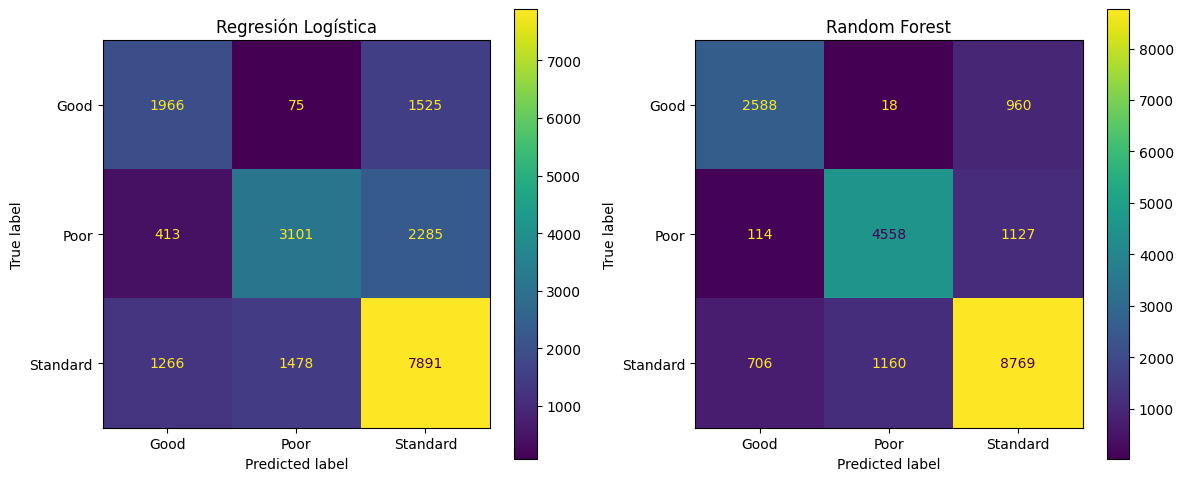

In [394]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Orden de las clases (para que todo quede alineado)
clases = sorted(y.unique())   # ['Good', 'Poor', 'Standard'] por ejemplo

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Regresión Logística ---
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    labels=clases,
    display_labels=clases,
    ax=axes[0]
)
axes[0].set_title("Regresión Logística")

# --- Random Forest ---
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    labels=clases,
    display_labels=clases,
    ax=axes[1]
)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()


### PARTIR EN VARIABLES DE ENTRENAMIENTO Y TESTEO 50/50

In [396]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

import pandas as pd

# Aquí asumo que ya tienes X_dummies y y construidos
# X_dummies: features con dummies
# y: columna Credit_Score

X_train, X_test, y_train, y_test = train_test_split(
    X_dummies,
    y,
    test_size=0.5,     
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape


((50000, 48), (50000, 48))

In [397]:
# Regresión Logística con escalado
logreg_pipe_50 = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=500,
        n_jobs=-1,
        solver="lbfgs",
        multi_class="auto"
    ))
])

# Random Forest
rf_clf_50 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)


In [398]:
logreg_pipe_50.fit(X_train, y_train)
rf_clf_50.fit(X_train, y_train)


C:\Users\COMPU\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [399]:
y_pred_log_50 = logreg_pipe_50.predict(X_test)
y_pred_rf_50  = rf_clf_50.predict(X_test)

acc_log_50 = accuracy_score(y_test, y_pred_log_50)
acc_rf_50  = accuracy_score(y_test, y_pred_rf_50)

f1_log_50 = f1_score(y_test, y_pred_log_50, average="macro")
f1_rf_50  = f1_score(y_test, y_pred_rf_50, average="macro")

resultados_50 = pd.DataFrame({
    "Modelo": ["Regresión Logística (50/50)", "Random Forest (50/50)"],
    "Accuracy": [acc_log_50, acc_rf_50],
    "F1_macro": [f1_log_50, f1_rf_50]
})

resultados_50


,Modelo,Accuracy,F1_macro
0,Regresión Logística (50/50),0.65054,0.619938
1,Random Forest (50/50),0.77260,0.755392


In [400]:
print("===== Regresión Logística 50/50 =====")
print("Accuracy:", acc_log_50)
print("F1_macro:", f1_log_50)
print(classification_report(y_test, y_pred_log_50))

print("\n===== Random Forest 50/50 =====")
print("Accuracy:", acc_rf_50)
print("F1_macro:", f1_rf_50)
print(classification_report(y_test, y_pred_rf_50))


===== Regresión Logística 50/50 =====
Accuracy: 0.65054
F1_macro: 0.6199383157943363
              precision    recall  f1-score   support

        Good       0.55      0.57      0.56      8914
        Poor       0.66      0.53      0.59     14499
    Standard       0.68      0.74      0.71     26587

    accuracy                           0.65     50000
   macro avg       0.63      0.62      0.62     50000
weighted avg       0.65      0.65      0.65     50000


===== Random Forest 50/50 =====
Accuracy: 0.7726
F1_macro: 0.7553923664040578
              precision    recall  f1-score   support

        Good       0.71      0.69      0.70      8914
        Poor       0.78      0.75      0.77     14499
    Standard       0.79      0.81      0.80     26587

    accuracy                           0.77     50000
   macro avg       0.76      0.75      0.76     50000
weighted avg       0.77      0.77      0.77     50000



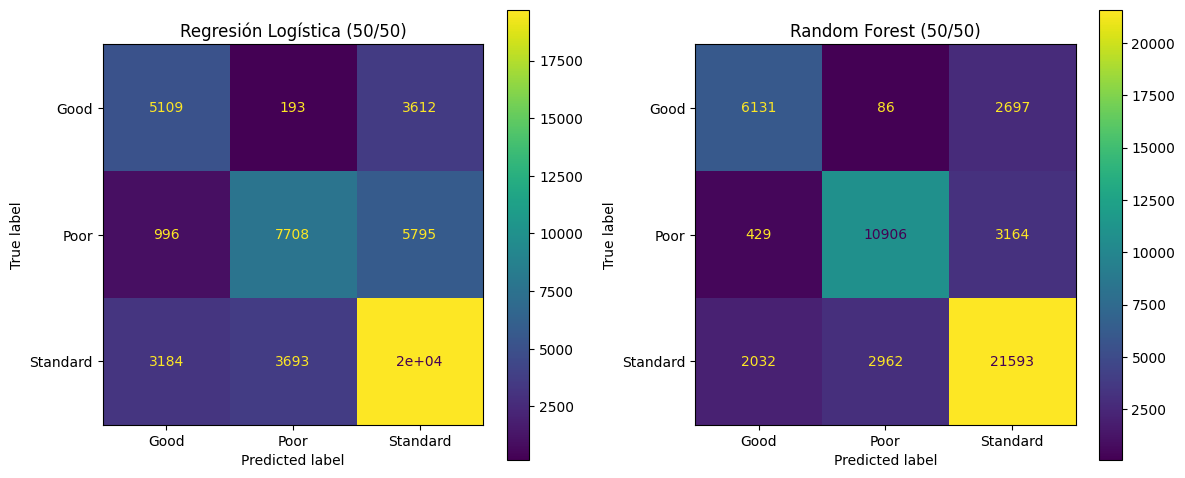

In [401]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Orden de clases (para que todo quede alineado)
clases = sorted(y.unique())   # ['Good', 'Poor', 'Standard'] en tu caso

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Regresión Logística 50/50 ---
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log_50,
    labels=clases,
    display_labels=clases,
    ax=axes[0]
)
axes[0].set_title("Regresión Logística (50/50)")

# --- Random Forest 50/50 ---
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_50,
    labels=clases,
    display_labels=clases,
    ax=axes[1]
)
axes[1].set_title("Random Forest (50/50)")

plt.tight_layout()
plt.show()


## PCA

In [402]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# 1) Split 80/20 (para el experimento “oficial” con PCA)
X_train, X_test, y_train, y_test = train_test_split(
    X_dummies,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2) Random Forest base (sin PCA)
rf_base = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

acc_rf_base = accuracy_score(y_test, y_pred_base)
f1_rf_base  = f1_score(y_test, y_pred_base, average="macro")

# 3) RF + PCA probando componentes
componentes = [12, 10, 9, 5, 3]
resultados_pca_rf = []

for n in componentes:
    print(f"Entrenando RF + PCA con {n} componentes...")
    
    pipe_pca_rf = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n, random_state=42)),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])
    
    pipe_pca_rf.fit(X_train, y_train)
    y_pred_pca = pipe_pca_rf.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred_pca)
    f1  = f1_score(y_test, y_pred_pca, average="macro")
    
    resultados_pca_rf.append({
        "Modelo": f"RF + PCA ({n} comp)",
        "Componentes": n,
        "Accuracy": acc,
        "F1_macro": f1
    })

# 4) Tabla de comparación
base_row = pd.DataFrame([{
    "Modelo": "Random Forest (sin PCA)",
    "Componentes": "Todos",
    "Accuracy": acc_rf_base,
    "F1_macro": f1_rf_base
}])

pca_rows = pd.DataFrame(resultados_pca_rf)

tabla_comparacion = pd.concat([base_row, pca_rows], ignore_index=True)
tabla_comparacion


Entrenando RF + PCA con 12 componentes...
Entrenando RF + PCA con 10 componentes...
Entrenando RF + PCA con 9 componentes...
Entrenando RF + PCA con 5 componentes...
Entrenando RF + PCA con 3 componentes...


,Modelo,Componentes,Accuracy,F1_macro
0,Random Forest (sin PCA),Todos,0.79575,0.782846
1,RF + PCA (12 comp),12,0.69395,0.666395
2,RF + PCA (10 comp),10,0.68730,0.659884
3,RF + PCA (9 comp),9,0.68565,0.657853
4,RF + PCA (5 comp),5,0.65305,0.621796
5,RF + PCA (3 comp),3,0.62370,0.589713


## CLUSTERING

In [403]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) Estandarizar features (clustering es muy sensible a escalas)
scaler_clust = StandardScaler()
X_scaled = scaler_clust.fit_transform(X_dummies)

# 2) PCA para reducir dimensiones (por ejemplo a 10)
pca_clust = PCA(n_components=10, random_state=42)
X_pca = pca_clust.fit_transform(X_scaled)

X_scaled.shape, X_pca.shape


((100000, 48), (100000, 10))

### Probar distintos k y calcular silhouette

In [405]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

ks = [2, 3, 4, 5, 6]
results_k = []

for k in ks:
    print(f"Entrenando KMeans con k = {k}...")
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels_k = kmeans.fit_predict(X_pca)
    
    sil = silhouette_score(
        X_pca,
        labels_k,
        sample_size=10000,   # <--- esto baja brutalmente el costo
        random_state=42
    )
    
    results_k.append({"k": k, "silhouette": sil})

results_k_df = pd.DataFrame(results_k)
results_k_df


Entrenando KMeans con k = 2...
Entrenando KMeans con k = 3...
Entrenando KMeans con k = 4...
Entrenando KMeans con k = 5...
Entrenando KMeans con k = 6...


,k,silhouette
0,2,0.269450
1,3,0.201654
2,4,0.189638
3,5,0.196653
4,6,0.157938


### K-Means final con k = 3

In [406]:
from sklearn.cluster import KMeans

k_opt = 3  # elegimos 3 clusters

kmeans_final = KMeans(
    n_clusters=k_opt,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_pca)

# Guardar los clusters en el df
df["cluster_k3"] = cluster_labels

df[["Credit_Score", "cluster_k3"]].head()


,Credit_Score,cluster_k3
0,Good,0
1,Good,0
2,Good,0
3,Good,0
4,Good,0


In [409]:
# Conteo crudo
tabla_clusters = pd.crosstab(df["cluster_k3"], df["Credit_Score"])
print("Conteo por cluster y clase:")
print(tabla_clusters)

# Porcentaje por fila (cada cluster, cómo se reparte en clases)
tabla_row = pd.crosstab(df["cluster_k3"], df["Credit_Score"], normalize="index")
print("\nDistribución por cluster (fila = cluster):")
print(tabla_row)

# Porcentaje por columna (cada clase, cómo se reparte en clusters)
tabla_col = pd.crosstab(df["cluster_k3"], df["Credit_Score"], normalize="columns")
print("\nDistribución por clase (columna = Credit_Score):")
print(tabla_col)


Conteo por cluster y clase:
Credit_Score   Good   Poor  Standard
cluster_k3                          
0             14909   4932     12568
1               539  19304     12446
2              2380   4762     28160

Distribución por cluster (fila = cluster):
Credit_Score      Good      Poor  Standard
cluster_k3                                
0             0.460027  0.152180  0.387794
1             0.016693  0.597851  0.385456
2             0.067418  0.134893  0.797689

Distribución por clase (columna = Credit_Score):
Credit_Score      Good      Poor  Standard
cluster_k3                                
0             0.836269  0.170081  0.236356
1             0.030233  0.665701  0.234062
2             0.133498  0.164218  0.529582


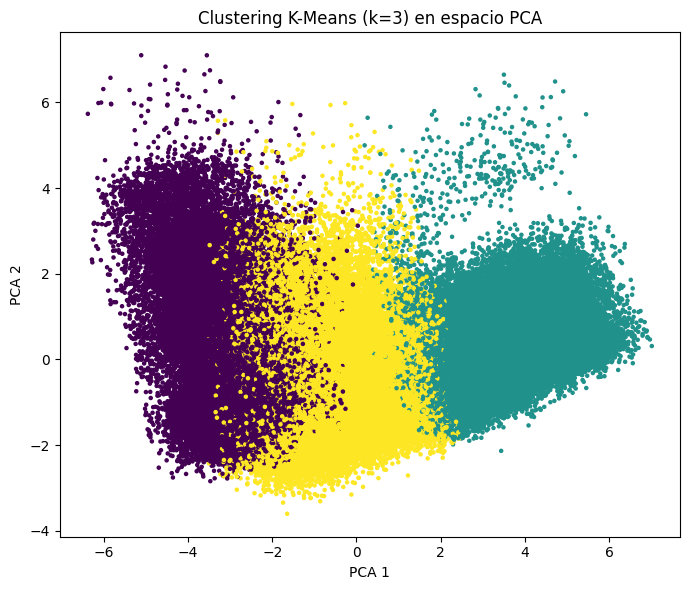

In [410]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    s=5
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Clustering K-Means (k=3) en espacio PCA")
plt.tight_layout()
plt.show()
